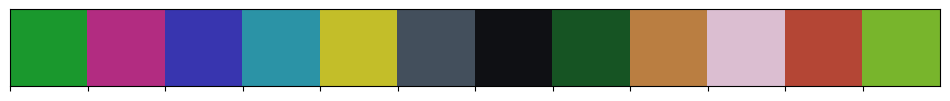

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
from tools.model_of_language import *
from utils.color_palette import *

This notebook introduces the `ModelOfLanguage` class, with many utilities to compute information quantities of sentences under interventions.

This code is heavily tailored to intervening a generic with different quantifying text at the sentence-initial position, but I think it can be used to do some other explorations too.

The base data structure is the `Sentence`.

- `id`: optional
- `context`: left-context of the target sentence, it will be prepended to the target on the forward pass
- `target`: target sentence to compute information quantities on
- `intervened_target`: (defaults to target) in case the inervention require a change in the sentence. Usually its target with the first letter lowercase.
- `target_measures`: Here will go the measures of the unintervened target
- `interventions`: List of `Intervention`
    - `text`: text that will be added when intervening
    - `measures`: here is where the surprisals, entropies & kldivs of this intervention will be
- `original_intervention_index`: if the ground truth sentence is an intervention (to compute kldiv)


In [2]:
sentence = Sentence(
    context='', 
    target='Postal workers are government employees.', 
    intervened_target='postal workers are government employees.',
    interventions=[
        Intervention(text="All"),
        Intervention(text="Most"),
        Intervention(text="Some"),
        Intervention(text="Few"),
        Intervention(text="No"),
    ]
)

The `ModelOfLanguage` class loads a model+tokenizer & has the utilities to calculate the information measures. The easiest way is to call the models by some nicknames (these are basically hardcoded):`Qwen3, Llama3.1, Qwen3-Instruct, Mistral7B, Llama3.1, Mistral8x22B, Mistral7B, gpt2`.

First we load the model!

In [3]:
mol = ModelOfLanguage('Mistral7B')

Model nickname set to: Mistral7B
Model name set to: mistralai/Mistral-7B-v0.3


Loading checkpoint shards: 100%|██████████| 3/3 [00:03<00:00,  1.31s/it]


Now let"s compute the information measures on the common tokens between target & intervened sentences! This method returns the sentence itself.

In [4]:
sentence = mol.get_measures_for_sentence(sentence)
print(sentence.pretty())

Sentence
- context: 
- target: Postal workers are government employees.
- intervened_target: postal workers are government employees.
- measure_tokens: ['al', '▁workers', '▁are', '▁government', '▁employees', '.']
- first_token_after_root_from_right: 3
- target_measures:
  - entropy: [4.5312, 4.6211, 4.2891, 5.5234, 1.0830, 2.5371]
  - surprisal: [3.8105, 2.1074, 2.1660, 10.9453, 0.2734, 1.4395]
  - kl_div: [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]
- interventions:
  [0] All
    - entropy: [3.8301, 4.3086, 3.6543, 5.2383, 1.1221, 2.3613]
    - surprisal: [2.5918, 2.2246, 1.5264, 7.1445, 0.2788, 1.1367]
    - kl_div: [3.9805, 4.1055, 0.5186, 1.4180, 0.0377, 0.2761]
  [1] Most
    - entropy: [3.2852, 4.2148, 4.3438, 5.4141, 0.6255, 2.2715]
    - surprisal: [3.6426, 1.5762, 1.6572, 5.4453, 0.1244, 1.3672]
    - kl_div: [4.4453, 4.5508, 0.8530, 2.5469, 0.1104, 0.1301]
  [2] Some
    - entropy: [3.4922, 4.0156, 3.7695, 5.8477, 1.3809, 2.2852]
    - surprisal: [3.2461, 1.2842, 1.8799, 

Now we can easily put this into a plot. Some pointers:
- Low surprisal means the ground truth token was easy to predict.
- Lower entropy means there are fewer candidate tokens (more certainty).
- KL-divergence compares the distributions on the tokens of an intervention with those of the original target sentence.

/tmp/ipykernel_3858977/2586338015.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_3858977/2586338015.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([r"{}".format(tick.get_text()) for tick in ax.get_xticklabels()], size=10)


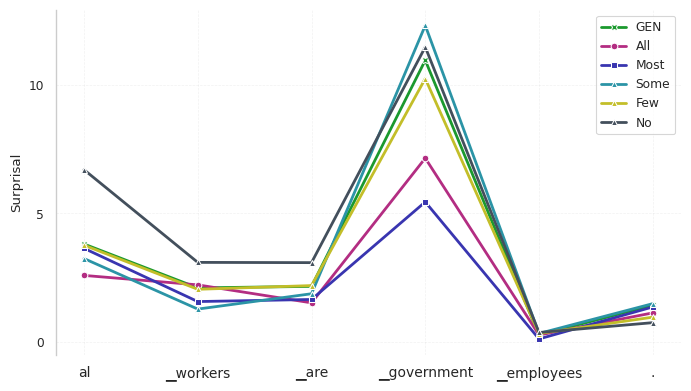

In [18]:
sns.set_style("whitegrid")
sns.set_context("paper")
# Set the custom palette
sns.set_palette(custom_palette)

def plot_sentence(sentence, save_path=None, measure_name="surprisal"):
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.lineplot(
            y=sentence.target_measures[measure_name],
            x=sentence.measure_tokens, 
            marker='X', 
            linestyle='-', 
            linewidth=2, 
            label=f"GEN",
            color=custom_palette[0],  # Use custom colors
            ax=ax
        )
    ax.set_xticklabels(ax.get_xticklabels())
    ax.set_yticks([0,5,10])
    # add a horizontal line at the mean of the target measures
    for i, intervention in enumerate(sentence.interventions):
        sns.lineplot(
            y=intervention.measures[measure_name], 
            x=sentence.measure_tokens, 
            marker='o' if i == 0 else 's' if i == 1 else '^', 
            linestyle='-', 
            linewidth=2, 
            label=f"{intervention.text}",
            color=custom_palette[i+1],  # Use custom colors
            ax=ax
        )
    ax.set_xticklabels([r"{}".format(tick.get_text()) for tick in ax.get_xticklabels()], size=10)
    # also bottom
    sns.despine(bottom=True)
    # generic

    plt.xlabel("")
    plt.ylabel(r"{}".format(measure_name.capitalize()))
    plt.title("")
    legend_labels = [r"Generic"] + [r"{}".format(intervention.text) for intervention in sentence.interventions]
    legend_handles = []
    # legend handles are small lineplots
    # from matplotlib.lines import Line2D

    # handles = [
    #     Line2D([0], [0], color=custom_palette[0], lw=2, ls="-", marker="X",  markeredgecolor="white",),
    #     Line2D([0], [0], color=custom_palette[1], lw=2, ls="-", marker="o",  markeredgecolor="white",),
    #     Line2D([0], [0], color=custom_palette[2], lw=2, ls="-", marker="s", markeredgecolor="white",),
    #     Line2D([0], [0], color=custom_palette[4], lw=2, ls="-", marker="^", markeredgecolor="white",),
    # ]

    # plt.legend(
    #     handles=handles,
    #     labels=legend_labels,
    #     fontsize=9,
    #     # set labels as \textrm
    #     # loc="upper right"
    #     loc="center left",
    #     bbox_to_anchor=(1.02, 0.5),
    #     borderaxespad=0.
    # )
    plt.grid(
        True,
        linestyle='--',
        linewidth=0.5,
        alpha=0.3,
        color='lightgray'
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format=save_path.split(".")[-1], bbox_inches='tight', dpi=300)
    plt.show()
plot_sentence(sentence, measure_name="surprisal")

We can observe that 'most' and 'all' are the ones that make it easier to predict 'government employees' after 'postal workers are'. But what happens if we change the context?

/tmp/ipykernel_3858977/2586338015.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
/tmp/ipykernel_3858977/2586338015.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([r"{}".format(tick.get_text()) for tick in ax.get_xticklabels()], size=10)


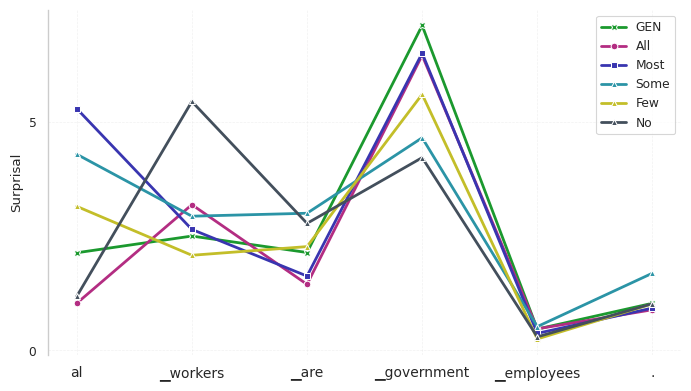

In [19]:
sentence = Sentence(
    context='In anarchocapitalist societies, there is barely any government at all. ', 
    target='Postal workers are government employees.', 
    intervened_target='postal workers are government employees.',
    interventions=[
        Intervention(text="All"),
        Intervention(text="Most"),
        Intervention(text="Some"),
        Intervention(text="Few"),
        Intervention(text="No"),
    ]
)
sentence = mol.get_measures_for_sentence(sentence)
plot_sentence(sentence, measure_name="surprisal")

Now 'no' is the quantifier that has the lowest surprisal on the '_government' token! Followed by 'some' and 'few'. I argue that the surprisal of the first post-verb token is extremely sensitive to these sort of intervention (and I do the lazy thing of averaging post-verb tokens because in arbitrary examples is hard to know what is the first content token).